In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
#import cmocean
import cartopy
cartopy.config['pre_existing_data_dir'] = '/home1/datawork/kbalem/cartopy_shapefiles/'
cartopy.config['data_dir'] = '/home1/datawork/kbalem/cartopy_shapefiles/'
cartopy.config['repo_data_dir'] = '/home1/datawork/kbalem/cartopy_shapefiles/'
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from cartopy.geodesic import Geodesic
Geodesic = Geodesic()
land_color = [85/255, 92/255, 105/255]
land_feature=cfeature.NaturalEarthFeature(category='physical',name='land',scale='50m',facecolor=land_color)
plt.rcParams['axes.grid'] = True
import numpy as np
import xarray as xr
import pandas as pd

import scipy.stats as stats
from sklearn.metrics import mean_squared_error
from math import radians
from sklearn.metrics.pairwise import haversine_distances

In [2]:
ds = xr.open_dataset('DeepArvorGrounding_ABYSS_2025-10-31.nc')
ds = ds.where(ds['jday_gps']>=np.datetime64('2023-12-01T00:00:00.00'),drop=True)
ds

<xarray.Dataset> Size: 117kB
Dimensions:    (N_GRD: 1629)
Dimensions without coordinates: N_GRD
Data variables:
    lat_gps    (N_GRD) float64 13kB 28.96 29.18 29.09 ... 40.88 40.98 40.96
    lon_gps    (N_GRD) float64 13kB -18.29 -18.12 -17.5 ... 7.162 7.485 7.774
    grnd       (N_GRD) float64 13kB 3.745e+03 3.775e+03 ... 2.826e+03 2.822e+03
    jday_grnd  (N_GRD) datetime64[ns] 13kB 2025-09-01T07:13:00 ... 2025-10-23...
    jae_grnd   (N_GRD) datetime64[ns] 13kB 2025-09-01T19:08:35 ... 2025-10-23...
    jday_gps   (N_GRD) datetime64[ns] 13kB 2025-09-01T19:24:37 ... 2025-10-23...
    jds_grnd   (N_GRD) datetime64[ns] 13kB 2025-09-01T19:27:33 ... 2025-10-23...
    wmo        (N_GRD) float64 13kB 1.903e+06 1.903e+06 ... 7.902e+06 7.902e+06
    cycle      (N_GRD) float64 13kB 3.0 4.0 6.0 7.0 8.0 ... 8.0 9.0 10.0 11.0

In [4]:
groundings_arvor = ds.to_dataframe().reset_index()
groundings_arvor = groundings_arvor[['lat_gps','lon_gps','grnd','wmo','cycle','jday_gps']]
groundings_arvor.columns = ['lat','lon','grnd','wmo','cycle','date']

In [5]:
groundings_arvor

,lat,lon,grnd,wmo,cycle,date
0,28.956770,-18.292130,3744.851213,1902620.0,3.0,2025-09-01 19:24:37
1,29.182420,-18.115188,3775.037329,1902620.0,4.0,2025-09-11 20:03:13
2,29.087100,-17.498740,3759.451862,1902620.0,6.0,2025-10-01 17:54:09
3,28.734248,-17.135287,3392.306693,1902620.0,7.0,2025-10-11 14:11:32
4,28.756397,-16.628078,3085.140099,1902620.0,8.0,2025-10-21 13:49:41
...,...,...,...,...,...,...
1624,40.989557,6.938547,2798.132621,7902326.0,7.0,2025-09-13 16:13:13
1625,40.867338,6.983842,2816.767140,7902326.0,8.0,2025-09-23 16:38:07
1626,40.879153,7.162092,2832.428778,7902326.0,9.0,2025-10-03 16:55:37
1627,40.980660,7.484690,2825.549430,7902326.0,10.0,2025-10-13 16:35:33


In [6]:
# GEBCO BATHY GRID
mbgrid = xr.open_dataset('/home1/datawork/kbalem/GEBCO24/GEBCO_2024_sub_ice_topo.nc')
mbgrid

<xarray.Dataset> Size: 7GB
Dimensions:    (lon: 86400, lat: 43200)
Coordinates:
  * lon        (lon) float64 691kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * lat        (lat) float64 346kB -90.0 -89.99 -89.99 ... 89.99 89.99 90.0
Data variables:
    crs        |S1 1B ...
    elevation  (lat, lon) int16 7GB ...
Attributes: (12/36)
    title:                           The GEBCO_2024 Grid - a continuous terra...
    summary:                         The GEBCO_2024 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_vertical_units:       meters
    geospatial_vertical_resolution:  1.0
    geospatial_vertical_positive:    up
    identifier_product_doi:          DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    references:                      DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    node_offset:                     1.0

In [7]:
# GEBCO TID GRID
tidgrid = xr.open_dataset('/home1/datawork/kbalem/GEBCO24/GEBCO_2024_TID.nc')
tidgrid

<xarray.Dataset> Size: 4GB
Dimensions:  (lon: 86400, lat: 43200)
Coordinates:
  * lon      (lon) float64 691kB -180.0 -180.0 -180.0 ... 180.0 180.0 180.0
  * lat      (lat) float64 346kB -90.0 -89.99 -89.99 -89.99 ... 89.99 89.99 90.0
Data variables:
    crs      |S1 1B ...
    tid      (lat, lon) int8 4GB ...
Attributes: (12/31)
    title:                           The GEBCO_2024 Grid Type Identifier
    summary:                         The GEBCO_2024 Grid is a continuous, glo...
    keywords:                        BATHYMETRY/SEAFLOOR TOPOGRAPHY, DIGITAL ...
    Conventions:                     CF-1.6, ACDD-1.3
    id:                              DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    naming_authority:                https://dx.doi.org
    ...                              ...
    geospatial_lon_max:              180.0
    geospatial_lon_units:            degrees_east
    geospatial_lon_resolution:       0.004166666666666667
    identifier_product_doi:          DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    references:                      DOI: 10.5285/1c44ce99-0a0d-5f4f-e063-708...
    node_offset:                     1.0

In [8]:
# Glorys mean to calculate horizontal uncertainty distance
glomu = xr.open_dataset('/home1/datawork/kbalem/Glorys_mean/mercatorglorys12v1_gl12_mean_uo-ave2000-2020-ave-all-deps.nc')
glomv = xr.open_dataset('/home1/datawork/kbalem/Glorys_mean/mercatorglorys12v1_gl12_mean_vo-ave2000-2020-ave-all-deps.nc')
glomus = xr.open_dataset('/home1/datawork/kbalem/Glorys_mean/mercatorglorys12v1_gl12_mean_uo-ave2000-2020-surf.nc')
glomvs = xr.open_dataset('/home1/datawork/kbalem/Glorys_mean/mercatorglorys12v1_gl12_mean_vo-ave2000-2020-surf.nc')
vspeed = 0.09 #m/s

In [9]:
def reduce_to_dist(lat,lon,d):
    r = np.ceil(d/110.)/2.
    subtgrid = tidgrid.sel(lon=slice(lon-r,lon+r),lat=slice(lat-r,lat+r))
    stacked_subtgrid = subtgrid.stack(k=('lat','lon'))
    stacked_subtgrid = stacked_subtgrid.dropna('k')
    around_points = np.column_stack([stacked_subtgrid['lat'].values,stacked_subtgrid['lon'].values])    
    result = haversine_distances(np.radians([lat,lon]).reshape(1, -1), np.radians(around_points))
    result=result*6371000/1000
    stacked_subtgrid['d']=('k',result.flatten())
    subtgrid = stacked_subtgrid.unstack()
    subtgrid = subtgrid.where(subtgrid['d']<=d,drop=True)
    return subtgrid 

In [10]:
tids={
0:'Land',
10:'Singlebeam',
11:'Multibeam',
12:'Seismic',
13:'Isolated sounding',
14:'ENC sounding',
15:'Lidar',
16:'Optical light sensor',
17:'Combination of direct measurement',
40:'Satellite-derived gravity data',
41:'Interpolated based on an algorithm',
42:'Digital bathymetric from charts',
43:'Digital bathymetric from ENCs',
44:'Bathymetric sounding',
45:'Predicted based on helicopter',
46:'Draft of a grounded iceberg',
70:'Pre-generated grid',
71:'Unknown source',
72:'Steering points'
}

6903039.0


/dev/shm/pbs.4213627.datarmor0/ipykernel_11152/2065841144.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  cc[i] = np.argwhere(c.values[i]==uc)[0].flatten()


Any direct sounding within 5k ? :  True


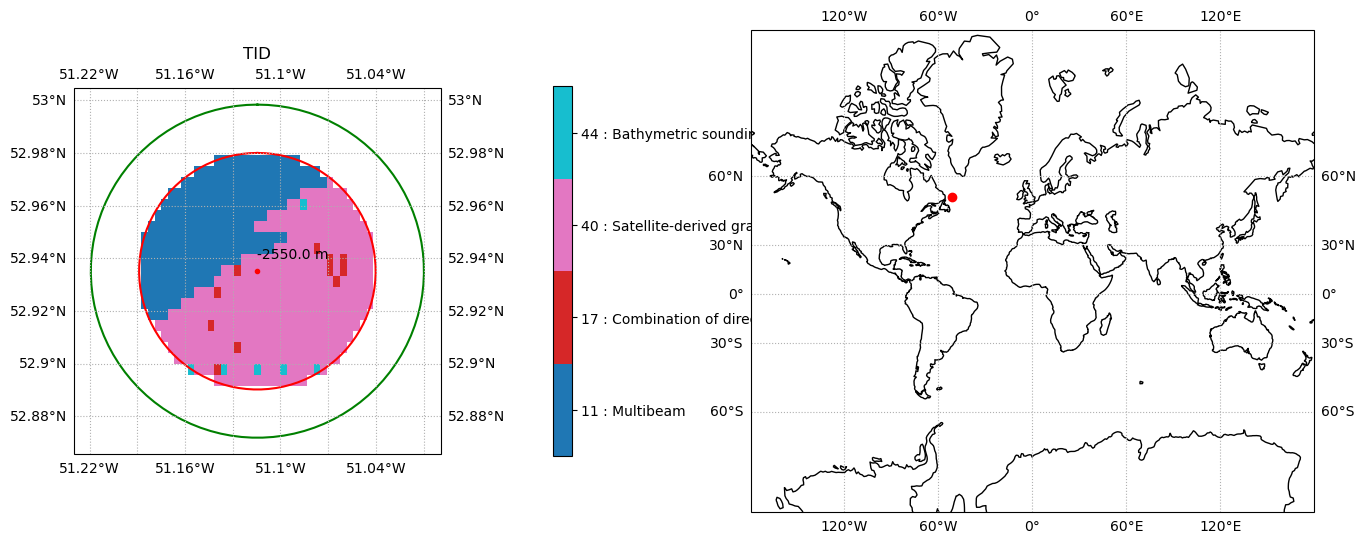

In [11]:
i=1000
ds=groundings_arvor
print(ds['wmo'].values[i])
lat, lon, grnd = ds['lat'].values[i], ds['lon'].values[i], ds['grnd'].values[i]
# GEBCO
elev = mbgrid['elevation'].interp(lon=lon,lat=lat,method='nearest').values
# UNCERTAINTY
vduration = grnd / vspeed
du = vduration*glomu['uo'].interp(latitude=lat,longitude=lon).values
dv = vduration*glomv['vo'].interp(latitude=lat,longitude=lon).values
hdist = np.round(np.sqrt(du**2 + dv**2),1)
# TIDs
subtgrid = reduce_to_dist(lat,lon,5)
# PLOT
c = subtgrid['tid'].stack(k=("lat", "lon"))
uc = np.unique(c.values)
uc = uc[~np.isnan(uc)]
sc = [str(int(i))+' : '+tids[i] for i in uc]
cc = np.zeros_like(c.values)*np.nan
for i in range(len(c.values)):
    if(~np.isnan(c.values[i])):
        cc[i] = np.argwhere(c.values[i]==uc)[0].flatten()
c.values = cc
c = c.unstack()
f=plt.figure(figsize=(16,8))
ax=f.add_subplot(121,projection=ccrs.Mercator())
ax.gridlines(linestyle=':',draw_labels=True)
a=c.plot(cmap=plt.get_cmap('tab10',len(uc)),vmin=0,vmax=len(uc),add_colorbar=False,ax=ax,transform=ccrs.PlateCarree())
cbar = plt.colorbar(a,pad=0.2,shrink=0.6)
cbar.set_ticks(np.arange(len(uc))+0.5,labels=sc)
ax.plot(lon,lat,'r.',transform=ccrs.PlateCarree())
ax.text(lon,lat+.005,str(elev)+' m ',color='k',transform=ccrs.PlateCarree())
ax.set_title('TID')

ci = Geodesic.circle(lon, lat, 5000,100,endpoint=True)
ci_u = Geodesic.circle(lon, lat, hdist,100,endpoint=True)
ax.plot(ci[:,0],ci[:,1],'r',transform=ccrs.PlateCarree())
ax.plot(ci_u[:,0],ci_u[:,1],'g',transform=ccrs.PlateCarree())

ax1=f.add_subplot(122,projection=ccrs.Mercator())
ax1.gridlines(linestyle=':',draw_labels=True)
ax1.coastlines()
ax1.plot(lon,lat,'ro',transform=ccrs.PlateCarree())
ax1.set_global()

direct_tids = [10,11,12,13,14,15,16,17]
print("Any direct sounding within 5k ? : ",np.any([tid in subtgrid['tid'] for tid in direct_tids]))

In [ ]:
flagz_arvor = np.zeros(len(groundings_arvor),dtype=int)-1
elevz_arvor = np.zeros(len(groundings_arvor),dtype=float)
hdist_arvor = np.zeros(len(groundings_arvor),dtype=float)

direct_tids = [10,11,12,13,14,15,16,17]
land_tids = [0]
radiuskm = 5

for i in range(len(flagz_arvor)):       
    lat, lon, grnd = groundings_arvor['lat'].values[i], groundings_arvor['lon'].values[i], groundings_arvor['grnd'].values[i]
    # GEBCO
    elevz_arvor[i] = mbgrid['elevation'].interp(lon=lon,lat=lat,method='nearest').values
    # UNCERTAINTY
    vduration = grnd / vspeed
    du = vduration*glomu['uo'].interp(latitude=lat,longitude=lon).values
    dv = vduration*glomv['vo'].interp(latitude=lat,longitude=lon).values
    hdist_arvor[i] = np.round(np.sqrt(du**2 + dv**2),1)
    # TID
    subtgrid = reduce_to_dist(lat,lon,radiuskm)
    if np.any([tid in subtgrid['tid'] for tid in direct_tids]):
        flagz_arvor[i]=9998    
    if np.any([tid in subtgrid['tid'] for tid in land_tids]):
        print("Carefull near the coast :",i)

In [ ]:
print('9998 : ',len(flagz_arvor[flagz_arvor==9998]))
print('-1 : ',len(flagz_arvor[flagz_arvor==-1]))

In [27]:
groundings_arvor['uncertainty2'] = hdist_arvor
groundings_arvor['tid_flag2'] = flagz_arvor
groundings_arvor['gebco2'] = elevz_arvor

In [28]:
groundings_arvor.to_csv('grounding_arvor_cmfile_2024-2025.csv',index=False)

Text(0, 0.5, 'Gebco bathy [m]')

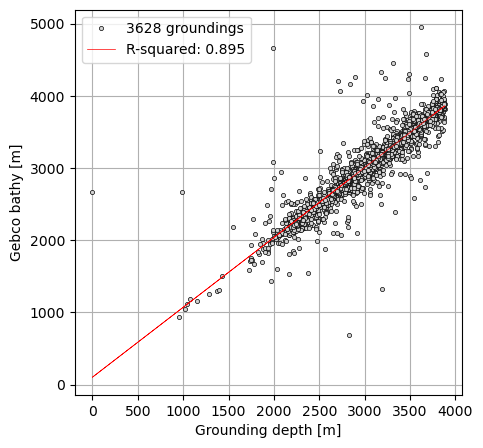

In [31]:
import scipy.stats as stats
x=groundings_arvor['grnd'].values
y=-1*groundings_arvor['gebco2'].values
res = stats.linregress(x, y)

fig,ax = plt.subplots(1,1,figsize=(5,5))
ax.plot(x,y,'o',label=f"{len(x)} groundings", color='lightgrey', markersize=3, markeredgecolor='k', markeredgewidth=0.5)
plt.plot(x, res.intercept + res.slope*x, 'r',linewidth=0.5,label=f"R-squared: {res.rvalue**2:.3f}")
#ax.set_xlim([1000,5000])
#ax.set_ylim([1000,5000])
ax.legend()
ax.set_xlabel('Grounding depth [m]')
ax.set_ylabel('Gebco bathy [m]')
#fig.savefig('groundingVsBathy.png')